![titanic](titanic.jpg)

## ABOUT THE DATA

Titanic Passenger Data

The dataset contains information about the passengers of the RMS Titanic, which sank on April 15, 1912, after colliding with an iceberg. The data includes attributes such as passenger class, age, gender, number of siblings/spouses aboard, number of parents/children aboard, ticket price, and embarkation location.

The dataset also includes information on whether the passenger survived the disaster.

The Titanic carried over 2,200 people, of whom over 1,500 perished, making this disaster one of the most tragic in maritime history.

Columns:

* **pclass** - Ticket class
* **survived** - Did the passenger survive the disaster
* **name** - Passenger name
* **sex** - Passenger gender
* **age** - Passenger age
* **sibsp** - Number of siblings/spouses aboard
* **parch** - Number of parents/children aboard
* **ticket** - Ticket number
* **fare** - Ticket price
* **cabin** - Cabin number
* **embarked** - Port of embarkation (C = Cherbourg, Q = Queenstown, S = Southampton)
* **boat** - Lifeboat number
* **body** - Body number (if the passenger did not survive and the body was recovered)
* **home.dest** - Destination

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('26__titanic.csv', sep=",")
df

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1.0,1.0,"Allen, Miss. Elisabeth Walton",female,29.0000,0.0,0.0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1.0,1.0,"Allison, Master. Hudson Trevor",male,0.9167,1.0,2.0,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1.0,0.0,"Allison, Miss. Helen Loraine",female,2.0000,1.0,2.0,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1.0,0.0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1.0,2.0,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1.0,0.0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1.0,2.0,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1305,3.0,0.0,"Zabour, Miss. Thamine",female,NaN,1.0,0.0,2665,14.4542,NaN,C,NaN,NaN,NaN
1306,3.0,0.0,"Zakarian, Mr. Mapriededer",male,26.5000,0.0,0.0,2656,7.2250,NaN,C,NaN,304.0,NaN
1307,3.0,0.0,"Zakarian, Mr. Ortin",male,27.0000,0.0,0.0,2670,7.2250,NaN,C,NaN,NaN,NaN
1308,3.0,0.0,"Zimmerman, Mr. Leo",male,29.0000,0.0,0.0,315082,7.8750,NaN,S,NaN,NaN,NaN


#### Przykładowe 20 kolumn:

In [3]:
df.sample(20)

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
303,1.0,0.0,"Warren, Mr. Frank Manley",male,64.0,1.0,0.0,110813,75.2500,D37,C,NaN,NaN,"Portland, OR"
1063,3.0,0.0,"Nirva, Mr. Iisakki Antino Aijo",male,41.0,0.0,0.0,SOTON/O2 3101272,7.1250,NaN,S,NaN,NaN,"Finland Sudbury, ON"
715,3.0,0.0,"Christmann, Mr. Emil",male,29.0,0.0,0.0,343276,8.0500,NaN,S,NaN,NaN,NaN
298,1.0,1.0,"Tucker, Mr. Gilbert Milligan Jr",male,31.0,0.0,0.0,2543,28.5375,C53,C,7,NaN,"Albany, NY"
1270,3.0,0.0,"Vande Walle, Mr. Nestor Cyriel",male,28.0,0.0,0.0,345770,9.5000,NaN,S,NaN,NaN,NaN
355,2.0,1.0,"Buss, Miss. Kate",female,36.0,0.0,0.0,27849,13.0000,NaN,S,9,NaN,"Sittingbourne, England / San Diego, CA"
422,2.0,0.0,"Gill, Mr. John William",male,24.0,0.0,0.0,233866,13.0000,NaN,S,NaN,155.0,"Clevedon, England"
179,1.0,0.0,"Klaber, Mr. Herman",male,NaN,0.0,0.0,113028,26.5500,C124,S,NaN,NaN,"Portland, OR"
718,3.0,0.0,"Coelho, Mr. Domingos Fernandeo",male,20.0,0.0,0.0,SOTON/O.Q. 3101307,7.0500,NaN,S,NaN,NaN,Portugal
672,3.0,0.0,"Betros, Master. Seman",male,NaN,0.0,0.0,2622,7.2292,NaN,C,NaN,NaN,NaN


## 1. UNDERSTANDING OF THE DATA:

#### INITIAL OBSERVATIONS: 
At first glance, we see that we do not have data for all passengers – as described, there were around 2,200, while our dataset contains 1,310 records. Most of them traveled in 3rd class, with significantly fewer passengers in 1st and 2nd class. In our sample, we have nearly half of the passengers who survived the disaster – it is possible that the dataset includes data for those who survived as well as those deceased who were identified. The ages of the passengers vary, and some records are missing this information. Most passengers traveled without families, and there is a predominance of male passengers. An interesting note is that ticket prices are highly varied, even within the same class. We see that the majority of passengers embarked on the Titanic at the port of "Southampton." However, when it comes to bodies, very few were recovered.

#### BASIC STATISTICS FOR NUMERIC COLUMNS:

In [4]:
df.describe()

,pclass,survived,age,sibsp,parch,fare,body
count,1309.000000,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000,121.000000
mean,2.294882,0.381971,29.881135,0.498854,0.385027,33.295479,160.809917
std,0.837836,0.486055,14.413500,1.041658,0.865560,51.758668,97.696922
min,1.000000,0.000000,0.166700,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,21.000000,0.000000,0.000000,7.895800,72.000000
50%,3.000000,0.000000,28.000000,0.000000,0.000000,14.454200,155.000000
75%,3.000000,1.000000,39.000000,1.000000,0.000000,31.275000,256.000000
max,3.000000,1.000000,80.000000,8.000000,9.000000,512.329200,328.000000


#### NUMBER OF UNIQUE VALUES THAT EACH COLUMN HAS:

In [5]:
unique_values_count = {col: df[col].nunique() for col in df.columns}
unique_values_count

{'pclass': 3,
 'survived': 2,
 'name': 1307,
 'sex': 2,
 'age': 98,
 'sibsp': 7,
 'parch': 8,
 'ticket': 929,
 'fare': 281,
 'cabin': 186,
 'embarked': 3,
 'boat': 27,
 'body': 121,
 'home.dest': 369}

#### DETAILED OBSERVATIONS: 
Interestingly, we can see that the average age was around 30 years, while the median was 28, indicating that most passengers were young individuals. The youngest participant was a two-month-old infant, and the oldest person was 80 years old. We also see that only 121 bodies were recovered from over 800 deceased individuals.

The ship had at least 186 cabins, which illustrates its size. The number of lifeboats used for evacuation was only 27.

## 2. MISSING VALUES:

In [6]:
missing_values_count = df.isnull().sum()
missing_values_count

pclass          1
survived        1
name            1
sex             1
age           264
sibsp           1
parch           1
ticket          1
fare            2
cabin        1015
embarked        3
boat          824
body         1189
home.dest     565
dtype: int64

#### OBSERVATIONS: 
We can see that there are 264 missing values in the "age" column. Additionally, a significant number of records are missing data regarding the cabin. In a few columns, there is only one value missing. Out of curiosity, we can check whether these missing values pertain to the same record:

In [7]:
df[df["pclass"] == None]

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest


#### OBSERVATIONS: 
Indeed, we can see in the section where we displayed the entire DataFrame that the last record with index 1309 is completely empty. Therefore, we can remove it.

In [8]:
df.dropna(subset='pclass', inplace=True)
df

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1.0,1.0,"Allen, Miss. Elisabeth Walton",female,29.0000,0.0,0.0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1.0,1.0,"Allison, Master. Hudson Trevor",male,0.9167,1.0,2.0,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1.0,0.0,"Allison, Miss. Helen Loraine",female,2.0000,1.0,2.0,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1.0,0.0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1.0,2.0,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1.0,0.0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1.0,2.0,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3.0,0.0,"Zabour, Miss. Hileni",female,14.5000,1.0,0.0,2665,14.4542,NaN,C,NaN,328.0,NaN
1305,3.0,0.0,"Zabour, Miss. Thamine",female,NaN,1.0,0.0,2665,14.4542,NaN,C,NaN,NaN,NaN
1306,3.0,0.0,"Zakarian, Mr. Mapriededer",male,26.5000,0.0,0.0,2656,7.2250,NaN,C,NaN,304.0,NaN
1307,3.0,0.0,"Zakarian, Mr. Ortin",male,27.0000,0.0,0.0,2670,7.2250,NaN,C,NaN,NaN,NaN


## 3. EXPLORATION OF INDIVIDUAL COLUMNS:

Text(0, 0.5, 'Frequency')

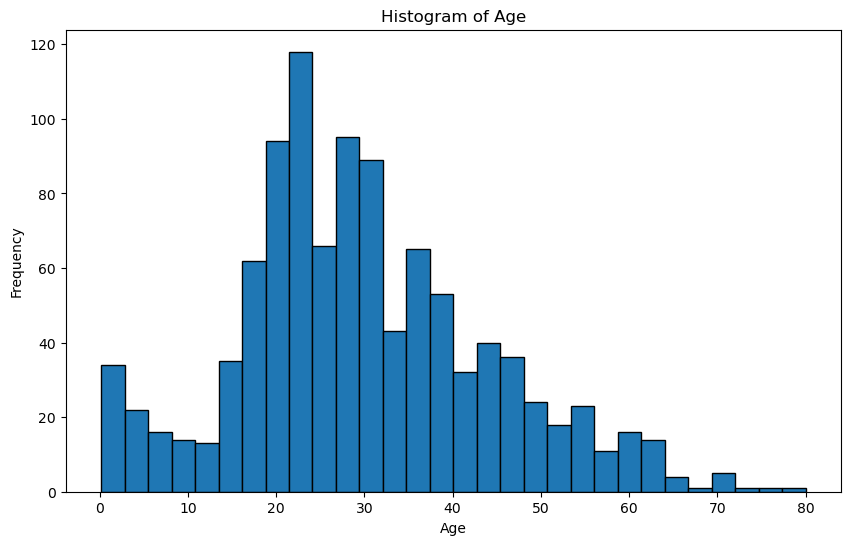

In [9]:
plt.figure(figsize=(10, 6))
plt.hist(df['age'].dropna(), bins=30, edgecolor='black')
plt.title('Histogram of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')

#### OBSERVATIONS: 
We see that the majority of individuals were between approximately 18 and 32 years old. We also note that there were relatively many young children, significantly more than elderly individuals over 60 years old.

Text(0, 0.5, 'Frequency')

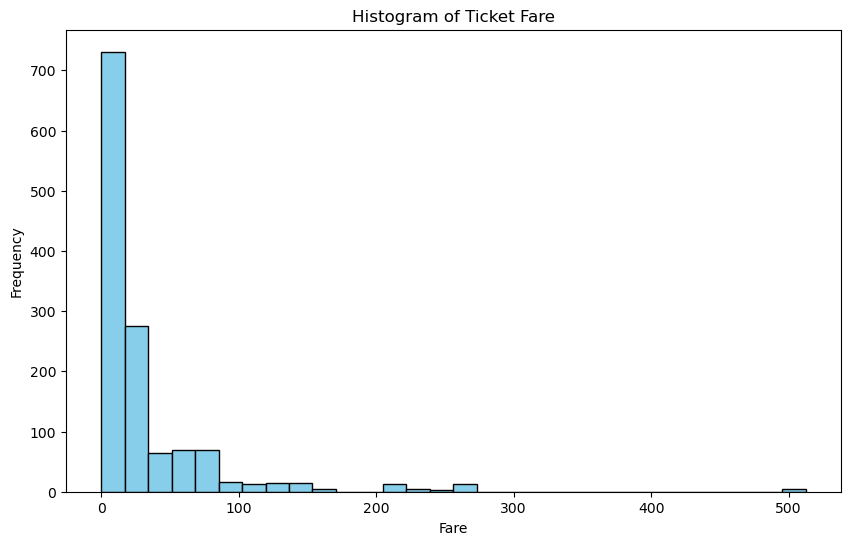

In [10]:
fare_data = df['fare'].dropna()

plt.figure(figsize=(10, 6))
plt.hist(fare_data, bins=30, color='skyblue', edgecolor='black')
plt.title('Histogram of Ticket Fare')
plt.xlabel('Fare')
plt.ylabel('Frequency')

#### OBSERVATIONS: 
The vast majority of tickets were purchased at the lowest price. There were very few tickets priced above 100.

(array([0, 1, 2]), [Text(0, 0, 'S'), Text(1, 0, 'C'), Text(2, 0, 'Q')])

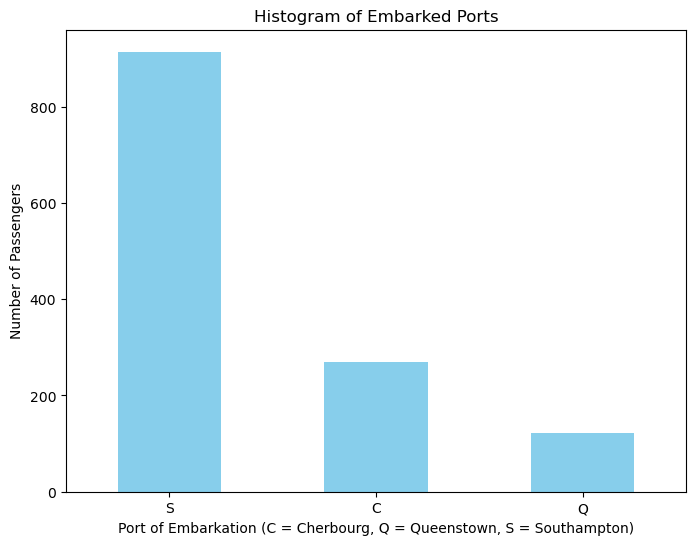

In [11]:
plt.figure(figsize=(8, 6))
df['embarked'].dropna().value_counts().plot(kind='bar', color='skyblue')
plt.title('Histogram of Embarked Ports')
plt.xlabel('Port of Embarkation (C = Cherbourg, Q = Queenstown, S = Southampton)')
plt.ylabel('Number of Passengers')
plt.xticks(rotation=0)

#### OBSERVATIONS: 
The majority of passengers definitely embarked from the port of Southampton.

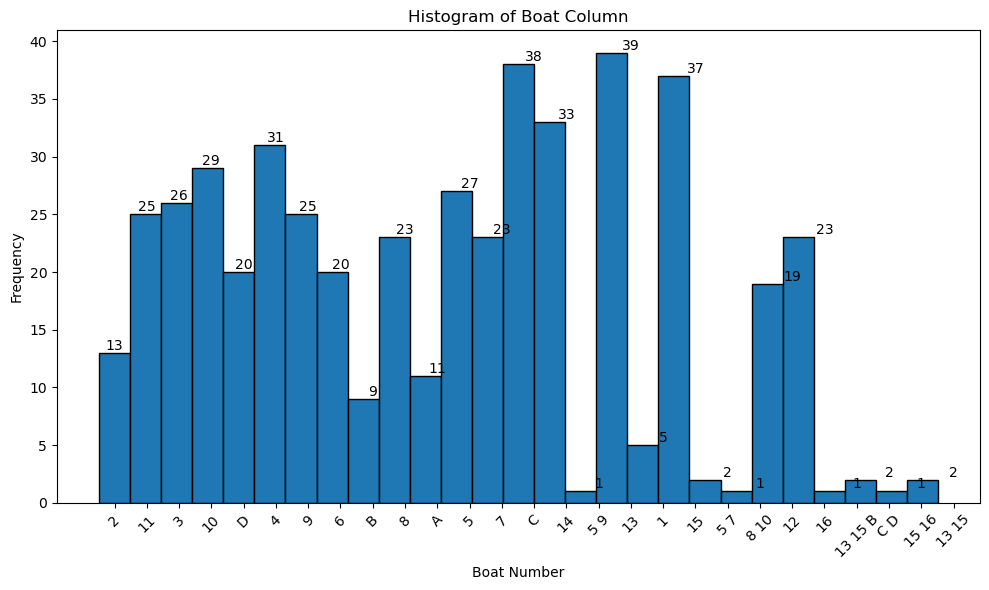

In [12]:
boat_data = df['boat'].dropna()

plt.figure(figsize=(10, 6))
counts, bins, patches = plt.hist(boat_data, bins=len(boat_data.unique()), align='left', edgecolor='black')

for count, bin, patch in zip(counts, range(len(bins)), patches):
    height = patch.get_height()
    if height > 0:
        plt.text(bin, height, f'{int(height)}', ha='center', va='bottom')

plt.title('Histogram of Boat Column')
plt.xlabel('Boat Number')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.tight_layout()

#### OBSERVATIONS: 
There were several lifeboats that had between 20 and 40 people aboard. There were also a few lifeboats that had literally only a few or a dozen passengers.

## 4. TRANSFORMATION OF THE DATA:

#### NUMBER OF MISSING VALUES IN EACH COLUMN:

In [13]:
df.isnull().sum()

pclass          0
survived        0
name            0
sex             0
age           263
sibsp           0
parch           0
ticket          0
fare            1
cabin        1014
embarked        2
boat          823
body         1188
home.dest     564
dtype: int64

#### OBSERVATIONS: 
We see that there is still one missing value in the 'fare' column. We can examine that record and try to fix it.

In [14]:
df[df['fare'].isna()]

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
1225,3.0,0.0,"Storey, Mr. Thomas",male,60.5,0.0,0.0,3701,NaN,NaN,S,NaN,261.0,NaN


#### OBSERVATIONS: 
Below, where we examined the correlations between columns, we see that the ticket price is associated with its class. Therefore, we can fill in this missing value with the average ticket price of 3rd class.

In [15]:
df[df['pclass'] == 3]['fare'].mean()
df.loc[df['fare'].isna(), 'fare'] = df[df['pclass'] == 3]['fare'].mean()

#### OBSERVATIONS: 
In some columns, we can replace the None values with the string 'Unknown'.

In [16]:
df = df.fillna({'cabin': 'Unknown', 'boat': 'Unknown', 'body': 'Unknown', 'home.dest': 'Unknown'})
df.isnull().sum()

pclass         0
survived       0
name           0
sex            0
age          263
sibsp          0
parch          0
ticket         0
fare           0
cabin          0
embarked       2
boat           0
body           0
home.dest      0
dtype: int64

#### OBSERVATIONS: 
In the 'embarked' column, we can fill in the two missing values with the most frequently occurring value 'S'.

In [17]:
df['embarked'] = df['embarked'].fillna('S')

#### OBSERVATIONS: 
The age column still has a relatively large number of missing values. We can fill them in with the average age from all records.

In [18]:
df['age'] = df['age'].fillna(df['age'].mean())

## 5. ANALYSIS OF RELATIONS BETWEEN COLUMNS:

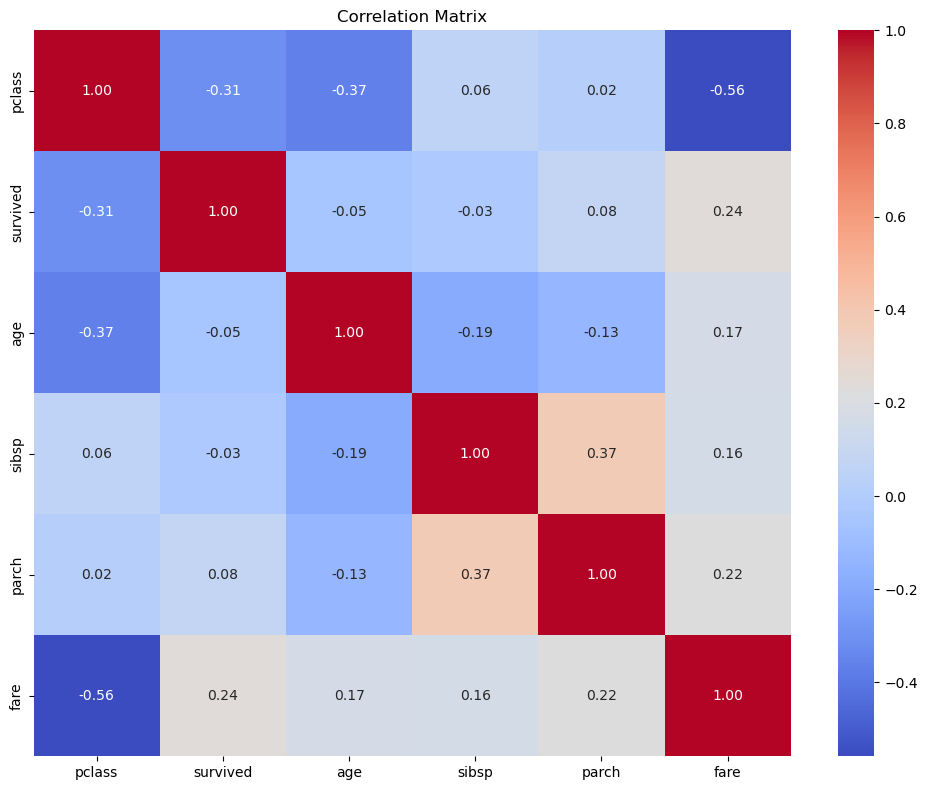

In [19]:
correlation_matrix = df.select_dtypes(include=['number']).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Correlation Matrix')
plt.tight_layout()

#### OBSERVATIONS: 
In most cases, we do not observe correlations between individual columns, although not all were included in the matrix. The only notable observation is a moderate inverse correlation between ticket class and ticket price. We can create a scatter plot of these two values; however, it will look quite specific due to the ticket class column having only 3 distinct values.

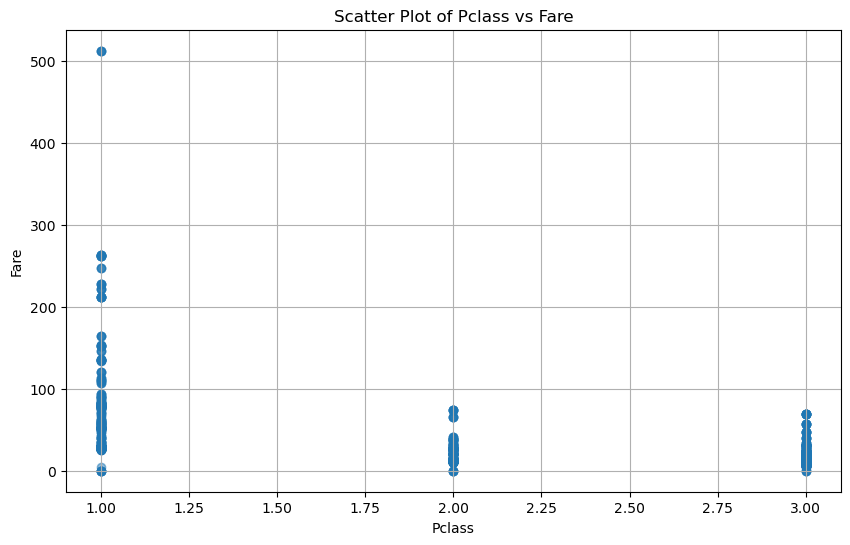

In [20]:
df_clean = df.dropna(subset=['pclass', 'fare'])

plt.figure(figsize=(10, 6))
plt.scatter(df_clean['pclass'], df_clean['fare'], alpha=0.5)
plt.title('Scatter Plot of Pclass vs Fare')
plt.xlabel('Pclass')
plt.ylabel('Fare')
plt.grid(True)

#### OBSERVATIONS: 
Delving deeper into the topic, we can check for any additional dependencies. First, we will investigate whether gender had an impact on survival rates.

In [ ]:
men_all = df[df['sex'] == 'male'].shape[0]
men_survived = df[(df['sex'] == 'male') & (df['survived'] == 1)].shape[0]
women_all = df[df['sex'] == 'female'].shape[0]
women_survived = df[(df['sex'] == 'female') & (df['survived'] == 1)].shape[0]

print(f'Survival rate of men: {round((men_survived / men_all) * 100, 2)}%')
print(f'Survival rate of women: {round((women_survived / women_all) * 100, 2)}%')

Procent przeżycia mężczyzn: 19.1%
Procent przeżycia kobiet: 72.75%


#### CONCLUSIONS: 
We can see that gender had a significant impact on passenger survival rates.

#### OBSERVATIONS: 
Next, we can check whether the ticket class had an impact on passenger survival.

In [22]:
survival_counts = df.groupby(['pclass', 'survived']).size().unstack(fill_value=0)

survival_percentages = survival_counts.div(survival_counts.sum(axis=1), axis=0) * 100

result_df = pd.concat([survival_counts, survival_percentages], axis=1, keys=['Count', 'Percentage'])

result_df

Count      Percentage           
survived   0.0  1.0        0.0        1.0
pclass                                   
1.0        123  200  38.080495  61.919505
2.0        158  119  57.039711  42.960289
3.0        528  181  74.471086  25.528914

#### CONCLUSIONS: 
Thus, we can see that ticket class also influenced passenger survival rates.

#### OBSERVATIONS: 
We can also investigate whether age had an impact on survival rates.

Text(0, 0.5, 'Age')

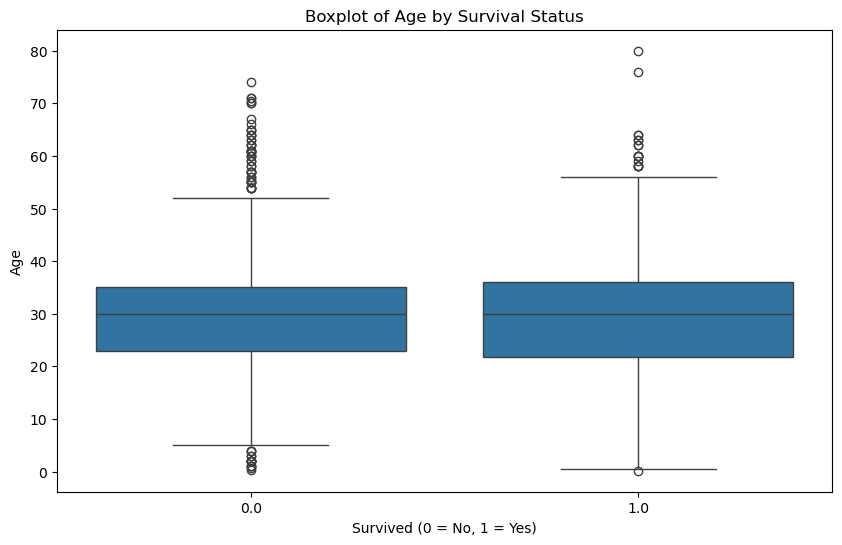

In [23]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='survived', y='age', data=df)
plt.title('Boxplot of Age by Survival Status')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Age')

#### CONCLUSIONS: 
We see that the boxplots are nearly identical for survivors and those who did not survive. Based on this, we can conclude that age did not have a significant impact on survival rates.

## 6. OUTLIERS:

(array([1]), [Text(1, 0, 'age')])

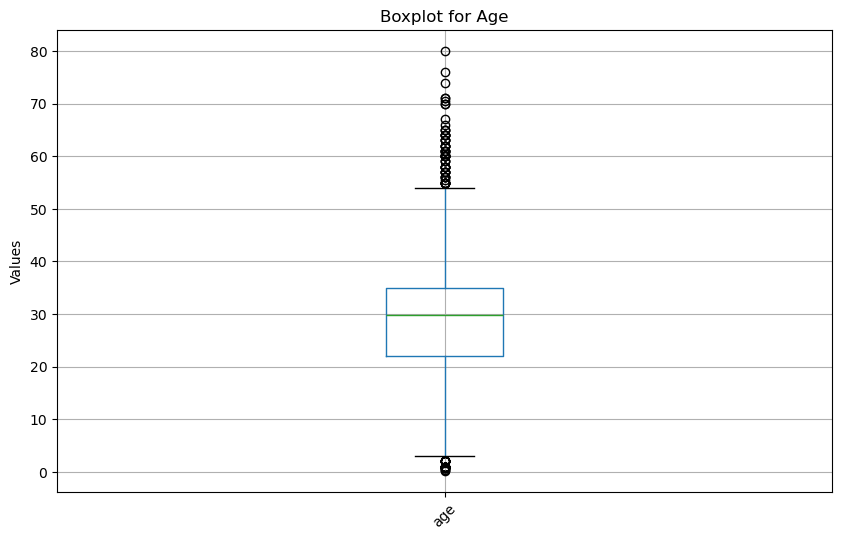

In [24]:
df_filtered = df[['age']].dropna()

plt.figure(figsize=(10, 6))
df_filtered.boxplot(column=['age'])
plt.title('Boxplot for Age')
plt.ylabel('Values')
plt.xticks(rotation=45)

#### OBSERVATIONS: 
We can create boxplots for the age column. We observe that half of the individuals are under 30 years old. Regarding outliers, there are a few individuals above the age of 66.

In [ ]:
df_filtered = df[['fare']].dropna()

plt.figure(figsize=(10, 6))
df_filtered.boxplot(column=['fare'])
plt.title('Boxplot for Fare')
plt.ylabel('Values')
plt.xticks(rotation=45)

#### OBSERVATIONS: 
We see that there are many outliers in terms of ticket prices, and they are quite widely dispersed.

## CONCLUSIONS: 
The data we received is not complete regarding all passengers of the disaster. However, from the available information, we can draw certain conclusions. Most individuals did not survive the disaster, with the majority being young men under 30 years old. Additionally, most passengers had third-class tickets, which were the cheapest. They boarded the Titanic at three different ports, with the majority coming from Southampton. Most of them were traveling without family.

Regarding the disaster itself, over half of the passengers perished. Only one in six bodies was recovered. Furthermore, there were only a few lifeboats, most of which carried between 20 and 40 passengers, which was definitely insufficient to save a larger portion of the passengers.

## CREATING A PREDICTIVE MODEL FOR PASSENGER SURVIVAL

In [26]:
from pycaret.classification import setup, compare_models, plot_model, save_model

Using the PyCaret library, I create an environment for training the model, excluding the "name" and "ticket" columns, which I believe will not impact its effectiveness:

In [27]:
setup(data=df, target="survived", ignore_features=["name", "ticket"], session_id=123)

,Description,Value
0,Session id,123
1,Target,survived
2,Target type,Binary
3,Original data shape,"(1309, 14)"
4,Transformed data shape,"(1309, 14)"
5,Transformed train set shape,"(916, 14)"
6,Transformed test set shape,"(393, 14)"
7,Ignore features,2
8,Numeric features,5
9,Categorical features,6


Next, I compare the performance of the models based on "Accuracy", as I am not particularly concerned with minimizing either group of false positives or false negatives:

In [28]:
best_model = compare_models()

,,
,,
Initiated,. . . . . . . . . . . . . . . . . .,13:18:07
Status,. . . . . . . . . . . . . . . . . .,Loading Dependencies
Estimator,. . . . . . . . . . . . . . . . . .,Compiling Library


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
ridge,Ridge Classifier,0.9760,0.9936,0.9486,0.9885,0.9678,0.9487,0.9496,0.0990
lda,Linear Discriminant Analysis,0.9760,0.9935,0.9486,0.9885,0.9678,0.9487,0.9496,0.0770
lr,Logistic Regression,0.9705,0.9941,0.9343,0.9884,0.9598,0.9367,0.9384,1.5880
gbc,Gradient Boosting Classifier,0.9705,0.9910,0.9486,0.9742,0.9608,0.9372,0.9379,0.1690
rf,Random Forest Classifier,0.9673,0.9856,0.9486,0.9657,0.9567,0.9304,0.9309,0.2350
et,Extra Trees Classifier,0.9673,0.9794,0.9514,0.9628,0.9568,0.9304,0.9308,0.1770
lightgbm,Light Gradient Boosting Machine,0.9673,0.9891,0.9486,0.9658,0.9567,0.9304,0.9310,0.2270
dt,Decision Tree Classifier,0.9597,0.9604,0.9514,0.9444,0.9475,0.9148,0.9153,0.0850
ada,Ada Boost Classifier,0.9432,0.9738,0.9314,0.9213,0.9259,0.8798,0.8804,0.1560
nb,Naive Bayes,0.9334,0.9780,0.9514,0.8841,0.9162,0.8611,0.8632,0.1050


Processing:   0%|          | 0/61 [00:00<?, ?it/s]

The best and fastest algorithm selected by PyCaret was the "Ridge Classifier," which achieved an accuracy of 97.6% in the test.

Teraz narysujemy "confusion matrix", aby zobaczyć liczbę błędów modelu:

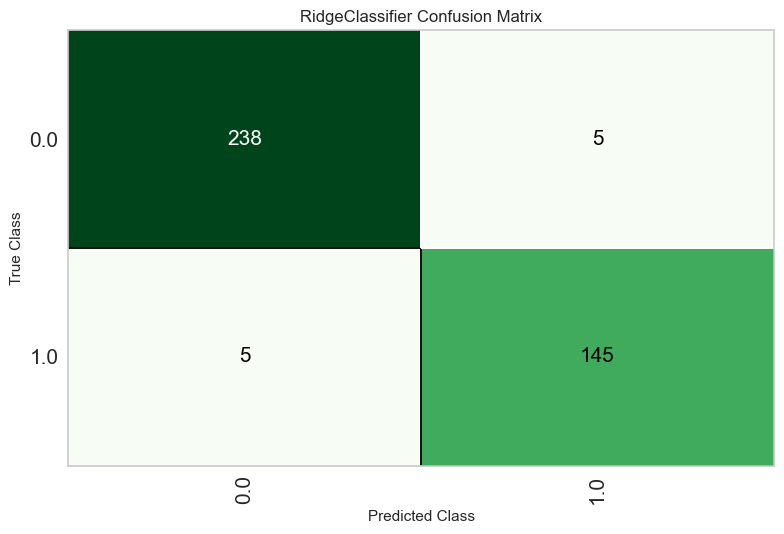

In [29]:
plot_model(best_model, plot="confusion_matrix")

We can see that the model made 10 errors out of 393 records, with 5 false positives and 5 false negatives.

We can also check which features had the greatest impact during training:

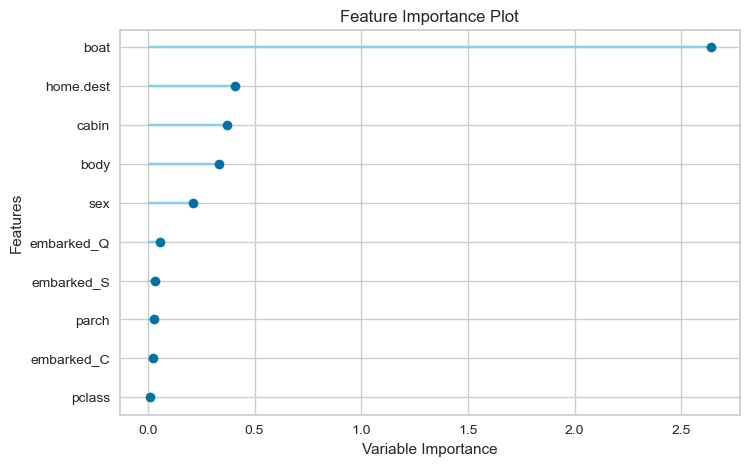

In [30]:
plot_model(best_model, plot='feature')

We see that the "boat" column had by far the greatest impact on the predictions.